# Filing missing data

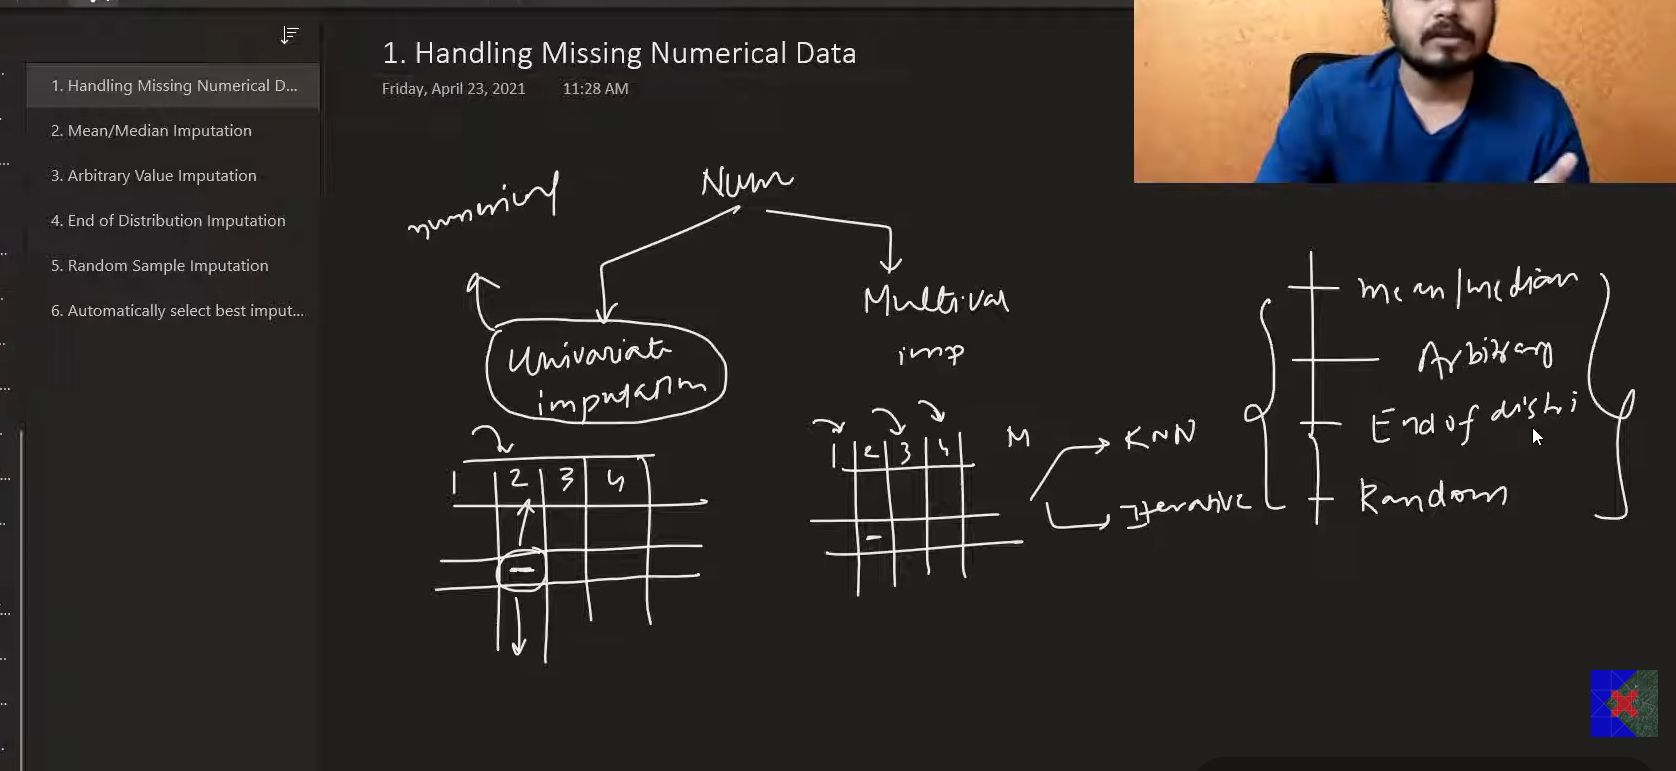

(1): Mean/Median imputation

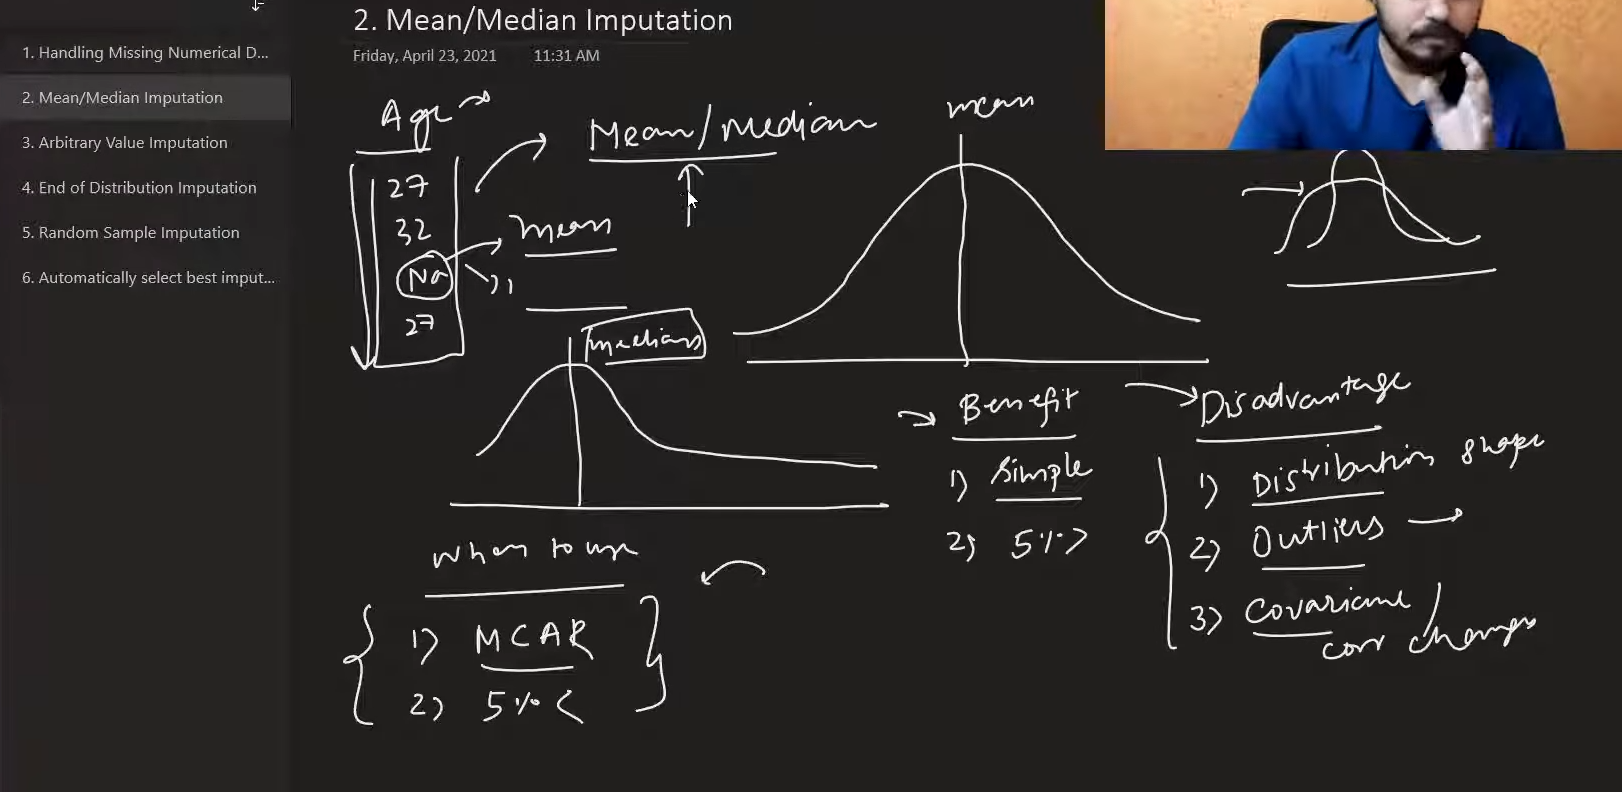
we use mean = if distribution is normal 
we use medain - when distribution is skewed

advantage:
* simple

Disadvantage:
*  it changes distribution shape
*  extra outliers come
*  covariant/correlation changes


When to use :
(1): mcar: when data is missing at random

(2) : if missing data <5 percent 



Generally when we do mean median imputation
variance shrinks.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [9]:
df = pd.read_csv('modifiedTitanic.csv')

In [10]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [12]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [13]:
x = df.drop(columns = ['Survived'])
y = df['Survived']

In [14]:
x_train,x_test,y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 2)

In [15]:
x_train.shape, x_test.shape

((712, 3), (179, 3))

In [16]:
x_train.isnull().mean()

Age       0.207865
Fare      0.050562
Family    0.000000
dtype: float64

In [17]:
mean_age = x_train['Age'].mean()
median_age = x_train['Age'].median()


mean_fare = x_train['Fare'].mean()
median_fare = x_train['Fare'].median()

In [18]:
 x_train['Age_median'] = x_train['Age'].fillna(median_age)
 x_train['Age_mean'] = x_train['Age'].fillna(mean_age)

 x_train['Fare_median'] = x_train['Fare'].fillna(median_age)
 x_train['Fare_mean'] = x_train['Fare'].fillna(mean_age)

In [19]:
x_train.sample(5)

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
170,61.0,33.500,0,61.00,61.000000,33.500,33.500
284,NaN,26.000,0,28.75,29.785904,26.000,26.000
88,23.0,263.000,5,23.00,23.000000,263.000,263.000
641,24.0,69.300,0,24.00,24.000000,69.300,69.300
716,38.0,227.525,0,38.00,38.000000,227.525,227.525


In [20]:
print('orignal age variable variance: ', x_train['Age'].var())
print('Age variance after median imputation: ', x_train['Age_median'].var())
print('Age variance after mean imputation: ', x_train['Age_mean'].var())



print('orignal Fare variable variance: ', x_train['Fare'].var())
print('Fare variance after median imputation: ', x_train['Fare_median'].var())
print('Fare variance after mean imputation: ', x_train['Fare_mean'].var())

orignal age variable variance:  204.3495133904614
Age variance after median imputation:  161.9895663346054
Age variance after mean imputation:  161.81262452718673
orignal Fare variable variance:  2448.197913706318
Fare variance after median imputation:  2324.9576136149317
Fare variance after mean imputation:  2324.623996772905


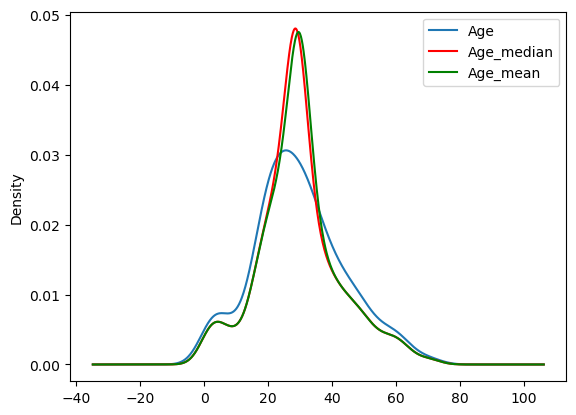

In [21]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution 
x_train['Age'].plot(kind = 'kde', ax =ax)


# variable imputed with the median
x_train['Age_median'].plot(kind = 'kde', ax =ax,color ='red')


# variable  imputed with mean
x_train['Age_mean'].plot(kind = 'kde', ax =ax,color ='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')


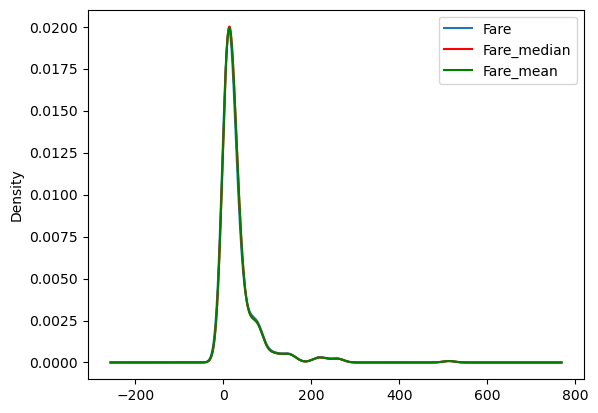

In [22]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution 
x_train['Fare'].plot(kind = 'kde', ax =ax)


# variable imputed with the median
x_train['Fare_median'].plot(kind = 'kde', ax =ax,color ='red')


# variable  imputed with mean
x_train['Fare_mean'].plot(kind = 'kde', ax =ax,color ='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')


In [23]:
x_train.cov()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,66.280487,66.383530
Fare,70.719262,2448.197914,17.258917,57.957599,55.603719,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-5.112563,-5.146106,16.404484,16.399278
Age_median,204.349513,57.957599,-5.112563,161.989566,161.812625,54.710043,54.793876
Age_mean,204.349513,55.603719,-5.146106,161.812625,161.812625,52.483705,52.565299
Fare_median,66.280487,2448.197914,16.404484,54.710043,52.483705,2324.957614,2324.765012
Fare_mean,66.383530,2448.197914,16.399278,54.793876,52.565299,2324.765012,2324.623997


In [24]:
x_train.corr()

,Age,Fare,Family,Age_median,Age_mean,Fare_median,Fare_mean
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.089604,0.089754
Fare,0.092644,1.000000,0.208268,0.091757,0.088069,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.242883,-0.244610,0.205710,0.205660
Age_median,1.000000,0.091757,-0.242883,1.000000,0.999454,0.089149,0.089292
Age_mean,1.000000,0.088069,-0.244610,0.999454,1.000000,0.085568,0.085707
Fare_median,0.089604,1.000000,0.205710,0.089149,0.085568,1.000000,0.999989
Fare_mean,0.089754,1.000000,0.205660,0.089292,0.085707,0.999989,1.000000


<Axes: >

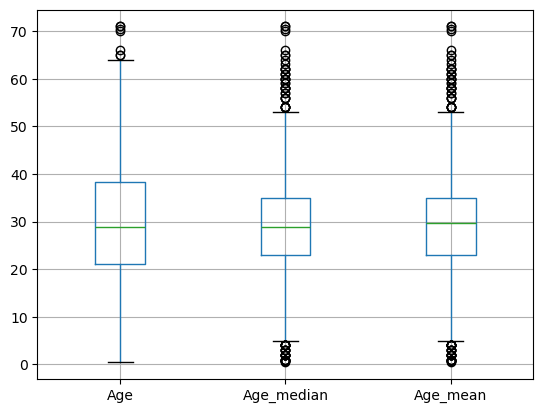

In [25]:
x_train[['Age','Age_median','Age_mean']].boxplot()

<Axes: >

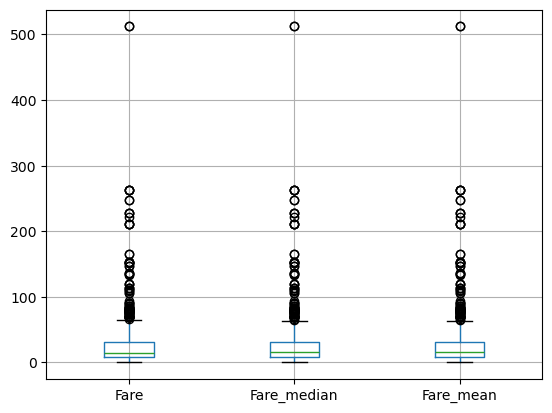

In [26]:
x_train[['Fare','Fare_median','Fare_mean']].boxplot()

 # Using Sklearn

In [27]:
x_train,x_test,y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 2)

In [28]:
imputer1 = SimpleImputer(strategy = 'median')
imputer2 = SimpleImputer(strategy = 'mean')

In [29]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder = 'passthrough')

In [30]:
trf.fit(x_train)

,transformers,"[('imputer1', ...), ('imputer2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


In [31]:
trf.named_transformers_['imputer1'].statistics_

array([28.75])

In [32]:
trf.named_transformers_['imputer2'].statistics_

array([32.61759689])

In [33]:
x_train = trf.transform(x_train)
x_test = trf.transform(x_test)

In [34]:
x_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 28.75  , 221.7792,   0.    ],
       [ 28.75  ,  25.925 ,   0.    ]], shape=(712, 3))

# (2): Arbitary value imputation

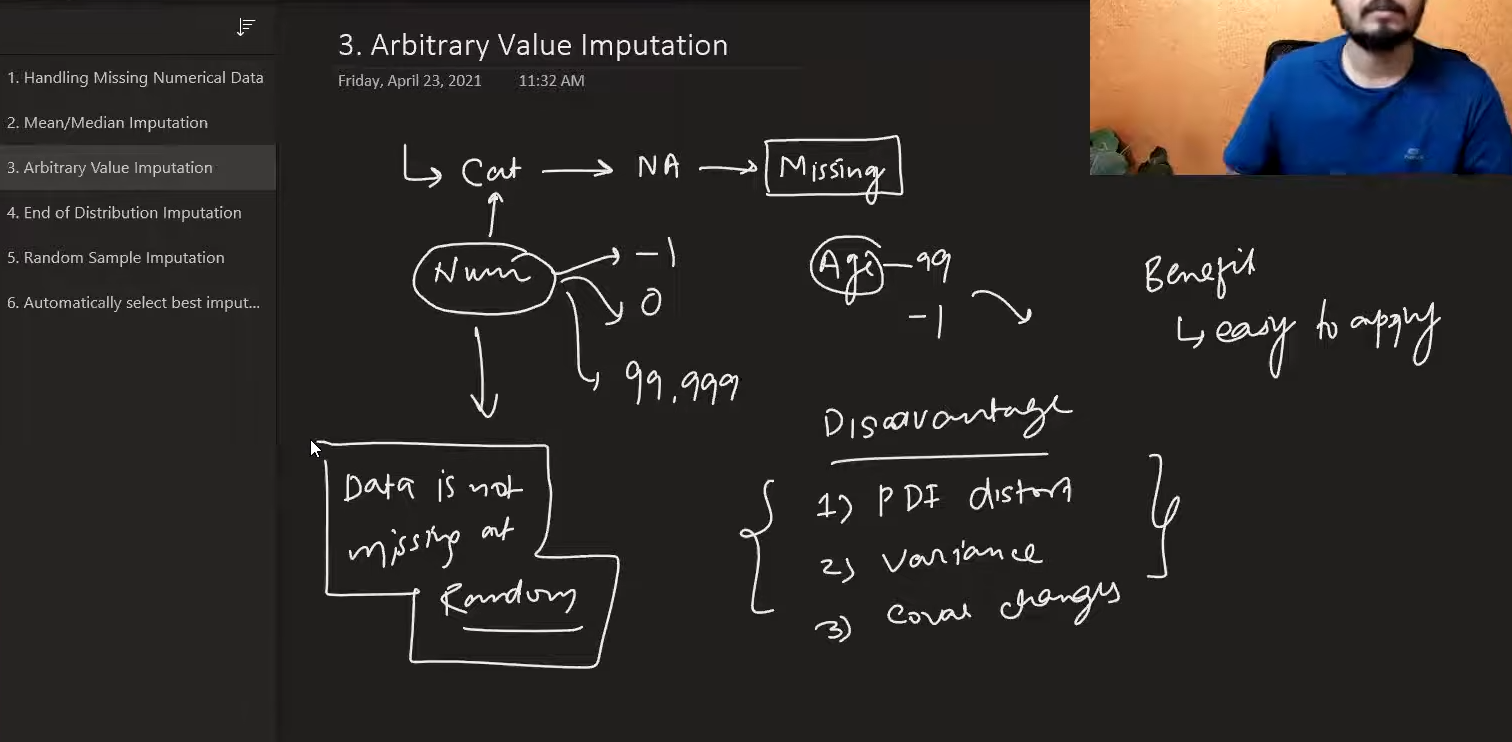

** we use this when data is not missing at random

here we fill all missing values by single value 
we mostly use this in categorical case

idea: we have to create difference data is missing 
and where data is not missing 


advantage: 
easy to apply 

disadvanatage:
* variance changes
* corelation/covariance changes
* PDF graph is distorted

In [35]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [37]:
df = pd.read_csv('modifiedTitanic.csv')

In [38]:
x = df.drop(columns = ['Survived'])
y = df['Survived']

In [39]:
x_train,x_test,y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 2)

In [40]:
 x_train['Age_99'] = x_train['Age'].fillna(99)
 x_train['Age_minus1'] = x_train['Age'].fillna(-1)

 x_train['Fare_999'] = x_train['Fare'].fillna(999)
 x_train['Fare_minus1'] = x_train['Fare'].fillna(-1)

In [41]:
x_train.sample(5)

,Age,Fare,Family,Age_99,Age_minus1,Fare_999,Fare_minus1
100,28.0,7.8958,0,28.0,28.0,7.8958,7.8958
428,NaN,7.7500,0,99.0,-1.0,7.7500,7.7500
104,37.0,7.9250,2,37.0,37.0,7.9250,7.9250
413,NaN,0.0000,0,99.0,-1.0,0.0000,0.0000
273,37.0,29.7000,1,37.0,37.0,29.7000,29.7000


In [42]:
print('orignal age variable variance: ', x_train['Age'].var())
print('Age variance after 99 wala imputation: ', x_train['Age_99'].var())
print('Age variance after -1 wala imputation: ', x_train['Age_minus1'].var())



print('orignal Fare variable variance: ', x_train['Fare'].var())
print('Fare variance after 99 wala imputation: ', x_train['Fare_999'].var())
print('Fare variance after -1 wala imputation: ', x_train['Fare_minus1'].var())

orignal age variable variance:  204.3495133904614
Age variance after 99 wala imputation:  951.7275570187172
Age variance after -1 wala imputation:  318.0896202624484
orignal Fare variable variance:  2448.197913706318
Fare variance after 99 wala imputation:  47219.20265217623
Fare variance after -1 wala imputation:  2378.5676784883503


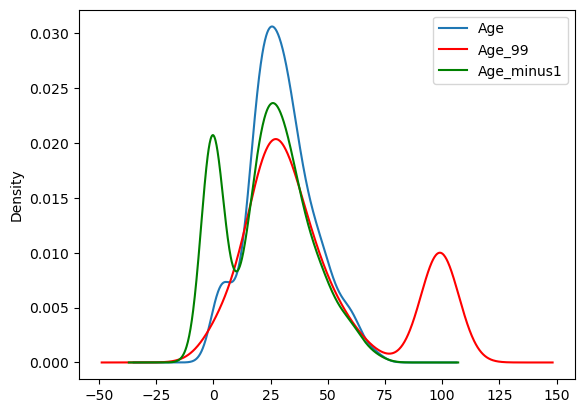

In [43]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution 
x_train['Age'].plot(kind = 'kde', ax =ax)


# variable imputed with the median
x_train['Age_99'].plot(kind = 'kde', ax =ax,color ='red')


# variable  imputed with mean
x_train['Age_minus1'].plot(kind = 'kde', ax =ax,color ='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')


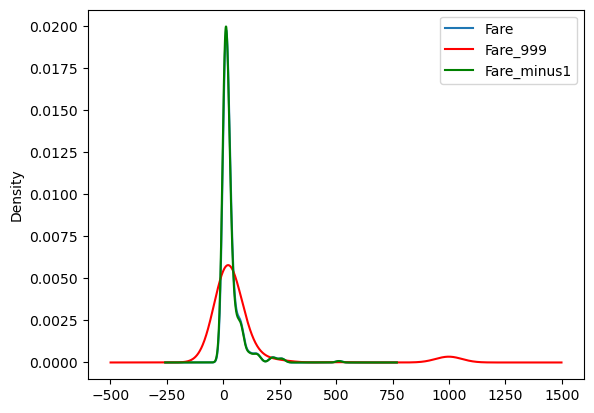

In [44]:
fig = plt.figure()
ax = fig.add_subplot(111)

# original variable distribution 
x_train['Fare'].plot(kind = 'kde', ax =ax)


# variable imputed with the median
x_train['Fare_999'].plot(kind = 'kde', ax =ax,color ='red')


# variable  imputed with mean
x_train['Fare_minus1'].plot(kind = 'kde', ax =ax,color ='green')

# add legends
lines, labels = ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')


In [45]:
x_train.cov()


,Age,Fare,Family,Age_99,Age_minus1,Fare_999,Fare_minus1
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,162.793430,63.321188
Fare,70.719262,2448.197914,17.258917,-101.671097,125.558364,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-7.387287,-4.149246,11.528625,16.553989
Age_99,204.349513,-101.671097,-7.387287,951.727557,-189.535540,-159.931663,-94.317400
Age_minus1,204.349513,125.558364,-4.149246,-189.535540,318.089620,257.379887,114.394141
Fare_999,162.793430,2448.197914,11.528625,-159.931663,257.379887,47219.202652,762.474982
Fare_minus1,63.321188,2448.197914,16.553989,-94.317400,114.394141,762.474982,2378.567678


In [46]:
x_train.corr()

,Age,Fare,Family,Age_99,Age_minus1,Fare_999,Fare_minus1
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.051179,0.084585
Fare,0.092644,1.000000,0.208268,-0.066273,0.142022,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.144787,-0.140668,0.032079,0.205233
Age_99,1.000000,-0.066273,-0.144787,1.000000,-0.344476,-0.023857,-0.062687
Age_minus1,1.000000,0.142022,-0.140668,-0.344476,1.000000,0.066411,0.131514
Fare_999,0.051179,1.000000,0.032079,-0.023857,0.066411,1.000000,0.071946
Fare_minus1,0.084585,1.000000,0.205233,-0.062687,0.131514,0.071946,1.000000


# Using scikit learn

In [47]:
x_train,x_test,y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 2)

In [48]:
imputer1 = SimpleImputer(strategy = 'constant',fill_value=99)
imputer2 = SimpleImputer(strategy = 'constant',fill_value=999)

In [49]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder = 'passthrough')

In [50]:
trf.fit(x_train)

,transformers,"[('imputer1', ...), ('imputer2', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'constant'
,fill_value,99


In [51]:
trf.named_transformers_['imputer1'].statistics_

array([99.])

In [52]:
trf.named_transformers_['imputer2'].statistics_

array([999.])

In [53]:
x_train = trf.transform(x_train)
x_test = trf.transform(x_test)

In [54]:
x_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 99.    , 221.7792,   0.    ],
       [ 99.    ,  25.925 ,   0.    ]], shape=(712, 3))

# (3): End of distribution

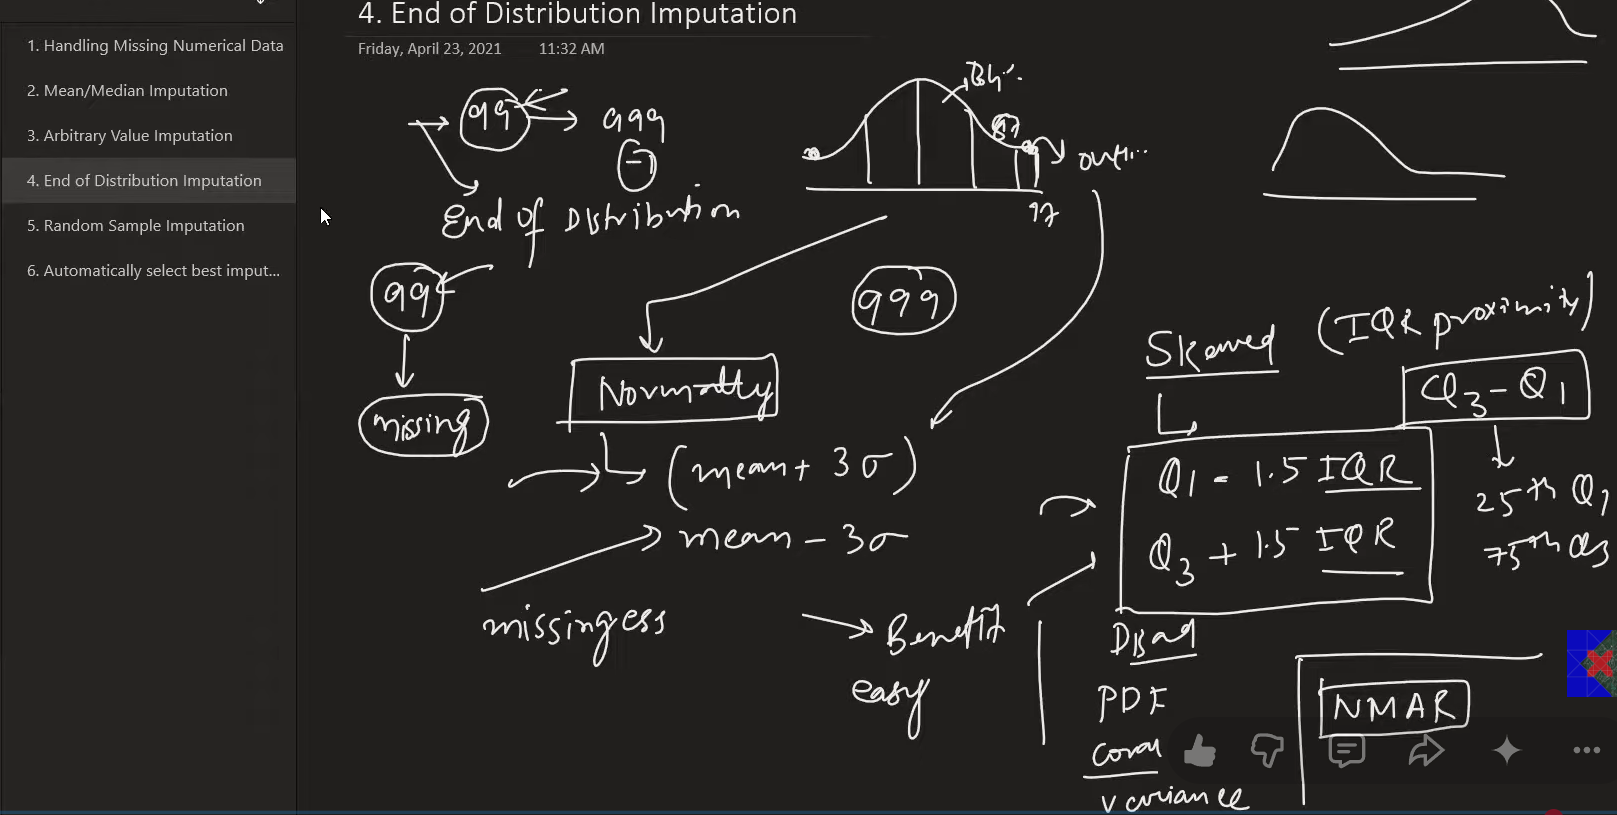
we take end value of distribution 

the column on which we are using the imputation if it is normally distributed 


means replace the missing values with outliers

when to use :
* when data is not missing at random